# La Palma Weekly Audit + EDA (LPA)

**Project:** Climate–Mortality

**Goal:** Reuse the same packed structure across islands, keeping the analytical sequence stable: QA → temperature → calima → interaction → short narrative close.

**Saved outputs:** QA tables and key descriptive tables (CSV) under reports/lpa/.


## 0. Setup
Parameters, paths, and shared helper utilities.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- island parameters: edit these four values ----

ISLAND_CODE = "lpa"
ISLAND_NAME = "la_palma"   # used in data/processed/<slug>/...
REPORT_CODE = "lpa"           # used in reports/<code>/
FIG_SLUG = "la_palma"      # used in reports/figures/islas/<slug>/eda
CALIMA_FILENAME = "calima_proxy_weekly_lpa_2015_2024_v2.parquet"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"


CWD : C:\dev\projects\climate_mortality\islands\la_palma
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\la_palma
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\la_palma
FP: C:\dev\projects\climate_mortality\data\processed\la_palma\master\master_lpa_2015_2024.parquet


## 1. Load data


In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)
display(checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start"))
display(num_summary(df))



EDA core weekly la_palma

--- eda_core_weekly_lpa ---
shape: (471, 37)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int64
confirmed_airports_max_week             int64
possible_airports_max_week              int6

,week_start,year,island,island_code,deaths_week,deaths_missing_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,la_palma,lpa,21.0,0,18.933333,21.966667,15.933333,72.000000,...,71.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,la_palma,lpa,17.0,0,19.314286,21.957143,16.671429,69.000000,...,77.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,la_palma,lpa,22.0,0,20.371429,23.085714,17.685714,69.142857,...,68.428571,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,la_palma,lpa,12.0,0,19.828571,22.985714,16.657143,65.428571,...,70.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,la_palma,lpa,13.0,0,19.800000,22.371429,17.350000,68.000000,...,82.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1272
4,deaths_nonnegative,True,neg=0


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,471.0,15.753715,4.817396,5.000000,12.000000,15.000000,19.000000,48.000000
deaths_missing_week,471.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temp_c_mean,464.0,21.293619,2.232826,16.528571,19.414286,21.128571,23.357143,26.814286
tmax_c_mean,464.0,23.776832,2.207746,18.814286,21.980952,23.628571,25.614286,30.257143
tmin_c_mean,464.0,18.809106,2.345665,14.057143,16.850000,18.664286,21.032143,24.000000
humidity_mean,464.0,69.646423,5.097058,42.428571,67.000000,70.214286,73.142857,87.000000
pressure_hpa_mean,471.0,1014.444990,3.053555,1001.150000,1012.492857,1014.042857,1016.032143,1024.028571
wind_ms_mean,471.0,5.333337,1.525474,2.166667,4.157143,5.242857,6.478571,9.285714
low_vis_confirmed_days_week,471.0,0.205945,0.527990,0.000000,0.000000,0.000000,0.000000,4.000000


In [4]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month
df = df.sort_values("week_start").reset_index(drop=True)

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
else:
    print("tmax_anom_mean already present.")

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")


calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / CALIMA_FILENAME
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]
    extra_keep = [c for c in ["cap_dust_yellow_plus_week", "cap_dust_level_max_week", "calima_dai_flag"] if c in calima.columns]
    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")


tmax_anom_mean already present.
excess_deaths already present or deaths_week missing.
Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\la_palma\calima\calima_proxy_weekly_lpa_2015_2024_v2.parquet
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [5]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

save_table(qa, TAB_DIR, f"qa_checks_{ISLAND_CODE}.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"missing_top50_{ISLAND_CODE}.csv")


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1279
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
rh_min_pct_week,287,0.6093
calima_level_week,146,0.3100
calima_dai_flag,146,0.3100
cap_dust_yellow_plus_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_coverage_week,129,0.2739
cap_heat_yellow_plus_week,129,0.2739
cap_dust_level_max_week,129,0.2739
PM2.5,12,0.0255
NO2,8,0.0170


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\qa_checks_lpa.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\missing_top50_lpa.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/la_palma/missing_top50_lpa.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [6]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week"
]
desc = num_summary(df, cols=core_cols)
display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
deaths_week,471.0,15.753715,4.817396,5.000000,12.000000,15.000000,19.000000,48.000000
temp_c_mean,464.0,21.293619,2.232826,16.528571,19.414286,21.128571,23.357143,26.814286
tmax_c_mean,464.0,23.776832,2.207746,18.814286,21.980952,23.628571,25.614286,30.257143
tmin_c_mean,464.0,18.809106,2.345665,14.057143,16.850000,18.664286,21.032143,24.000000
humidity_mean,464.0,69.646423,5.097058,42.428571,67.000000,70.214286,73.142857,87.000000
pressure_hpa_mean,471.0,1014.444990,3.053555,1001.150000,1012.492857,1014.042857,1016.032143,1024.028571
wind_ms_mean,471.0,5.333337,1.525474,2.166667,4.157143,5.242857,6.478571,9.285714
PM10,471.0,48.560611,60.570865,7.428571,21.642857,33.571429,51.285714,740.285714
PM2.5,459.0,18.184791,17.931806,3.571429,8.214286,12.142857,21.428571,164.571429
SO2,471.0,9.952937,7.282096,1.000000,6.000000,8.000000,12.142857,73.428571


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\desc_core_lpa.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/la_palma/desc_core_lpa.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\la_palma\lpa_eda01_weekly_deaths_timeseries.png


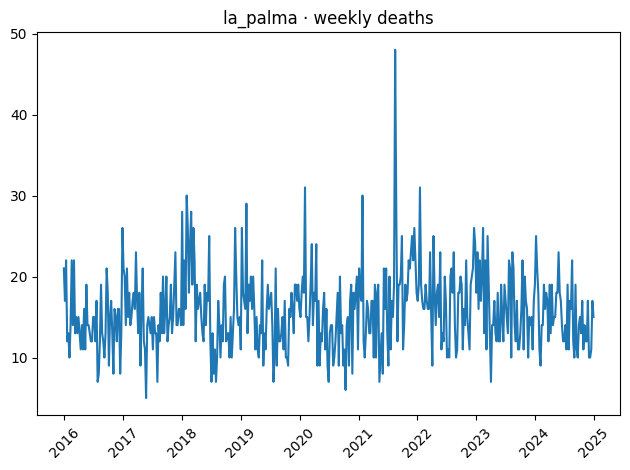

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\la_palma\lpa_eda01_weekly_tmax_timeseries.png


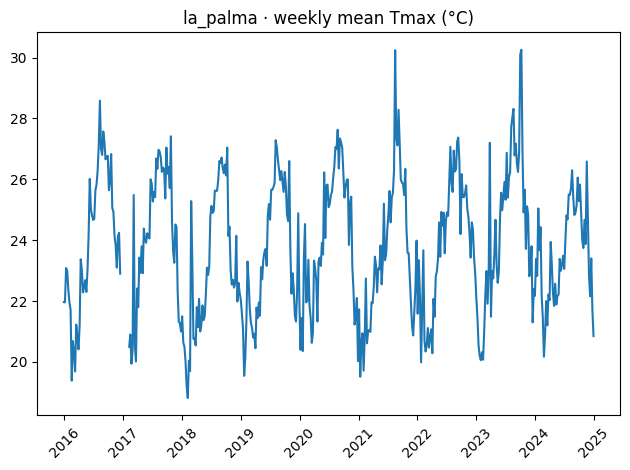

In [7]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df["week_start"], df["tmax_c_mean"])
plt.title(f"{ISLAND_NAME} · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\la_palma\lpa_eda01_deaths_vs_absolute_tmax_scatter.png


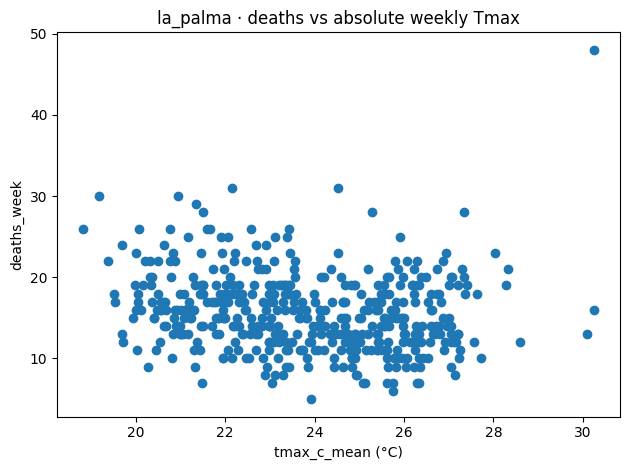

corr(deaths, tmax_c_mean): -0.1685


In [8]:
plt.figure()
plt.scatter(df["tmax_c_mean"], df["deaths_week"])
plt.xlabel("tmax_c_mean (°C)")
plt.ylabel("deaths_week")
plt.title(f"{ISLAND_NAME} · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\la_palma\lpa_eda01_deaths_vs_temperature_anomaly_scatter.png


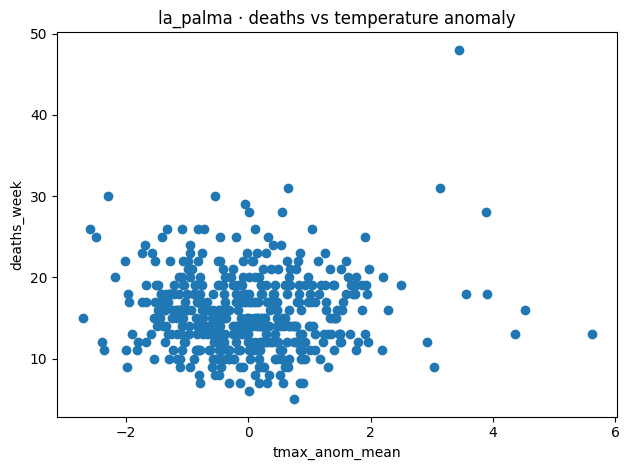

corr(deaths, tmax_anom_mean): 0.0242


In [9]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [10]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

tab_p95 = df.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)


Official heat thresholds from tmax_c_mean -> p90=26.62, p95=27.07
heat_p95
0    447
1     24
Name: count, dtype: int64


,count,mean,median
heat_p95,,,
0,447,15.668904,15.0
1,24,17.333333,17.0


Δ deaths (heat_p95 vs baseline): 1.66
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\heat_p95_deaths_lpa.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/la_palma/heat_p95_deaths_lpa.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\calima_proxy_audit_missing_lpa.csv


,calima_proxy_level_v2,weeks
0,no_calima,279
1,possible,150
2,probable,22
3,intense,20


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\calima_proxy_level_counts_lpa.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\la_palma\lpa_eda01_calima_proxy_level_counts.png


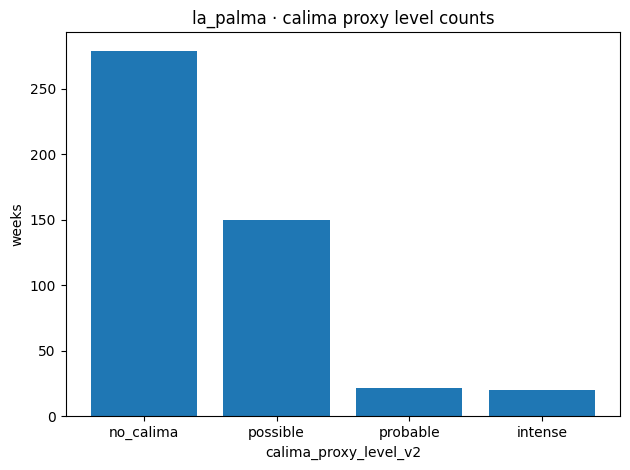

CAP yellow alignment with proxy (probable+intense among CAP yellow): 0.75


In [11]:
proxy_cols = ["calima_proxy_score_v2", "calima_proxy_level_v2"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={"index": "column"}), TAB_DIR, f"calima_proxy_audit_missing_{ISLAND_CODE}.csv", index=False)

    proxy_counts = (
        df["calima_proxy_level_v2"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level_v2")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level_v2"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index])

        plt.figure()
        plt.bar(plot_counts.index.astype(str), plot_counts.values)
        plt.title(f"{ISLAND_NAME} · calima proxy level counts")
        plt.xlabel("calima_proxy_level_v2")
        plt.ylabel("weeks")
        plt.tight_layout()
        autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_calima_proxy_level_counts.png")
        plt.show()

    if {"cap_dust_yellow_plus_week", "calima_proxy_level_v2"}.issubset(df.columns):
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        print("CAP yellow alignment with proxy (probable+intense among CAP yellow):", round(float(alignment), 4))
else:
    print("No calima proxy level column found in this master.")


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).


In [12]:
if "calima_proxy_level_v2" in df.columns:
    cal = df.groupby("calima_proxy_level_v2")["deaths_week"].agg(["count", "mean", "median"])
    level_order = ["no_calima", "possible", "probable", "intense"]
    cal = cal.reindex([x for x in level_order if x in cal.index])
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v2_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level_v2. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)


,count,mean,median
calima_proxy_level_v2,,,
no_calima,279,15.577061,15.0
possible,150,15.673333,15.0
probable,22,17.045455,16.5
intense,20,17.400000,16.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\calima_proxy_level_v2_deaths_lpa.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [13]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

extreme_conditions = ((tmp["heat_p95"] == 1) & (tmp["calima_intense"] == 1)).sum()
print("Weeks with temp_95 and calima_intense: ", extreme_conditions)

if extreme_conditions > 0:
    print("Weeks in extreme conditions:/n")
    print(tmp.loc[(tmp["heat_p95"] == 1) & (tmp["calima_intense"] == 1),
        ["week_start", "deaths_week", "tmax_c_mean", "tmax_anom_mean", "calima_proxy_level_v2"]])

save_table(inter.reset_index(), TAB_DIR, f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)


count       mean  median
heat_p95 calima_intense                          
0        0                 427  15.587822    15.0
         1                  20  17.400000    16.0
1        0                  24  17.333333    17.0

Weeks with temp_95 and calima_intense:  0
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\la_palma\interaction_heat_p95_x_calima_intense_lpa.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/la_palma/interaction_heat_p95_x_calima_intense_lpa.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **1.66**
- Δ deaths (calima intense vs no_calima): **+1.83 deaths/week**
- Proxy coverage / missingness: **0%**
- CAP yellow alignment with proxy: **0.75**
- corr(deaths, tmax_c_mean): **-0.1685**
- corr(deaths, Tmax anomaly): **0.0242**


### Summary – La Palma 

This exploratory analysis for La Palma follows the same audit structure used in the other islands, combining QA checks, temperature analysis, calima proxy evaluation, and simple joint-exposure exploration.

The weekly dataset shows good basic completeness, and the calima proxy variables have no missing values. Proxy coverage is therefore complete at the data level, although this should not be interpreted as proof of perfect proxy validity. Agreement between CAP yellow alerts and the calima proxy is moderate (0.75), which supports usefulness but does not fully validate the proxy.

Absolute temperature remains negatively correlated with mortality (corr(deaths, tmax_c_mean) = -0.1685), which is consistent with seasonal confounding rather than a direct protective effect of heat. Temperature anomalies were used to reduce this seasonal distortion, but the anomaly-based association is still close to zero (corr(deaths, tmax anomaly) = 0.0242), suggesting that any heat-related signal is weak in this dataset.

Extreme heat weeks (heat_p95 = 1) show a small increase in mortality relative to baseline (+1.66 deaths/week). Intense calima weeks also show a small increase relative to no_calima weeks (+1.83 deaths/week). These differences are directionally interesting, but they remain small in magnitude and should be interpreted cautiously.

The joint-exposure table shows an important limitation: there are no weeks in the current weekly sample met both conditions simultaneously (heat_p95 = 1 and calima_intense = 1). This means that a combined heat–calima interaction cannot be assessed for La Palma in the current weekly sample.

Overall, the La Palma EDA suggests weak and uncertain associations between mortality, heat, and calima. The main value of this block is descriptive: it identifies small directional differences, confirms strong seasonal structure, and clarifies that evidence for compound exposure effects is currently unavailable due to zero overlap in the extreme categories.